In [1]:
# install PyTorch and torchvision
!pip install -q torch torchvision matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.5 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


In [5]:

JSON_PATH = '/content/drive/MyDrive/photos.json'
ZIP_PATH  = '/content/drive/MyDrive/photos.zip'

In [6]:
EXTRACT_DIR = '/content/photos'

In [7]:
import os
if not os.path.isdir(EXTRACT_DIR):
    !unzip -q "{ZIP_PATH}" -d "{EXTRACT_DIR}"


In [8]:
import json

photos = []
with open(JSON_PATH, 'r') as f:
    first = f.read(1)
    f.seek(0)
    if first == '[':
        # Standard JSON array
        photos = json.load(f)
    else:
        # Newline‑delimited JSON (NDJSON)
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                photos.append(json.loads(line))
            except json.JSONDecodeError:
                # skip invalid lines
                continue
print(f"Loaded {len(photos)} photo entries.")
print("Example entry:", photos[0])

Loaded 200100 photo entries.
Example entry: {'photo_id': 'zsvj7vloL4L5jhYyPIuVwg', 'business_id': 'Nk-SJhPlDBkAZvfsADtccA', 'caption': 'Nice rock artwork everywhere and craploads of taps.', 'label': 'inside'}


In [9]:

print(photos[0])
print("Keys:", photos[0].keys())

# If there's no 'photo_id', look for something like 'id' or 'photoId'


{'photo_id': 'zsvj7vloL4L5jhYyPIuVwg', 'business_id': 'Nk-SJhPlDBkAZvfsADtccA', 'caption': 'Nice rock artwork everywhere and craploads of taps.', 'label': 'inside'}
Keys: dict_keys(['photo_id', 'business_id', 'caption', 'label'])


In [10]:
import os
from glob import glob

# List top-level contents
print("Top‑level dirs:", os.listdir(EXTRACT_DIR))

# Find all .jpg/.jpeg/ .png under it
all_imgs = glob(os.path.join(EXTRACT_DIR, "**", "*.*"), recursive=True)
all_imgs = [p for p in all_imgs if p.lower().endswith(('.jpg','.jpeg','.png'))]
print(f"Found {len(all_imgs)} total image files.")
for p in all_imgs[:10]:
    print(" ", p)


Top‑level dirs: ['photos']
Found 200098 total image files.
  /content/photos/photos/Kwb10iQC31pZzvEBIeIvrQ.jpg
  /content/photos/photos/nTyYVwtdNGbfrxGwt6VESA.jpg
  /content/photos/photos/-BPnJsCeD7rQQLOmBevxGw.jpg
  /content/photos/photos/fqnHpca1gzqVfSfYzeB3kw.jpg
  /content/photos/photos/hFDoTb0BzcE6TGktW5EQvQ.jpg
  /content/photos/photos/bb7Go0Z5o3uXbAMS0kDPHA.jpg
  /content/photos/photos/-iOfceq4xA75Ub6QRsWo3w.jpg
  /content/photos/photos/pStAFQmdw3nABsMy5gBLHA.jpg
  /content/photos/photos/Q1sWlQ-8Z9D4b0ETtM8xOA.jpg
  /content/photos/photos/mK82ZzGK99zJ2oOh_cwHRQ.jpg


In [11]:
from glob import glob
image_paths = glob(os.path.join(EXTRACT_DIR, "**", "*.jpg"), recursive=True)
print(f"Using all {len(image_paths)} JPGs on disk.")


Using all 200098 JPGs on disk.


In [12]:
from glob import glob
import os

# 1. Grab *all* image files in one go
all_files = glob(os.path.join(EXTRACT_DIR, "**", "*.*"), recursive=True)
# keep only typical image extensions
all_imgs  = [p for p in all_files if p.lower().endswith(('.jpg','jpeg','png'))]

# 2. Build a dict:  basename → full path
file_map = { os.path.splitext(os.path.basename(p))[0] : p
             for p in all_imgs }

# 3. Now match JSON entries in O(1) time each
image_paths = []
for entry in photos:
    key = entry.get('photo_id') or entry.get('id')  # whatever your field is
    if key in file_map:
        image_paths.append(file_map[key])

print(f"Matched {len(image_paths)}/{len(photos)} JSON entries to files.")


Matched 200100/200100 JSON entries to files.


In [13]:
from PIL import Image

valid_paths = []
for p in image_paths:
    try:
        with Image.open(p) as img:
            img.verify()
        valid_paths.append(p)
    except Exception:
        print("Skipping broken:", p)

print(f" {len(valid_paths)}/{len(image_paths)} files are valid.")
image_paths = valid_paths

Skipping broken: /content/photos/photos/ydm3g1wUWSxJnMPgHk2JhQ.jpg
Skipping broken: /content/photos/photos/JGpfPj8VEvnq1B-Xqr3w-A.jpg
Skipping broken: /content/photos/photos/bf3ymV0YgP7B6rEoriaU2w.jpg
Skipping broken: /content/photos/photos/juDNZOOnkgG3QINFrulsAg.jpg
Skipping broken: /content/photos/photos/9X4YPM8nYFjf7hY8xUdc6Q.jpg
Skipping broken: /content/photos/photos/N6hL8FQ84A2DznF2S2Lp7g.jpg
Skipping broken: /content/photos/photos/pY32hIagdxrL4Nsi959EQg.jpg
Skipping broken: /content/photos/photos/cNkUV0sInfh_Py5PP8SHtQ.jpg
Skipping broken: /content/photos/photos/Pk87_8Yndygr4LRUD_H7Hg.jpg
Skipping broken: /content/photos/photos/ke4ohxa93GJz0KH9H2kwsQ.jpg
Skipping broken: /content/photos/photos/rLafN9k3_AF5lZU0cs3LZg.jpg
Skipping broken: /content/photos/photos/-YAvSvGUs2ugiJUvIRO6Jw.jpg
Skipping broken: /content/photos/photos/feUGw0P5byOq4U40C77tyQ.jpg
Skipping broken: /content/photos/photos/pW1IPuTdLIUB61goirbXaA.jpg
Skipping broken: /content/photos/photos/RLtBKD2rlfTaELWejmLBCA

In [14]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
])

class YelpPhotoDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img)

# rebuild
dataset = YelpPhotoDataset(image_paths, transform=transform)
loader  = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4, drop_last=True)

print(f" New DataLoader built with {len(dataset)} samples, {len(loader)} batches.")


 New DataLoader built with 199994 samples, 1562 batches.


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [15]:
import torch, torch.nn as nn
import torch.nn.functional as F

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        # Encoder
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),   # 64→32
            nn.Conv2d(32,64, 4, 2, 1), nn.ReLU(),   # 32→16
            nn.Conv2d(64,128,4, 2, 1), nn.ReLU(),   # 16→8
            nn.Flatten()
        )
        self.fc_mu     = nn.Linear(128*8*8, latent_dim)
        self.fc_logvar = nn.Linear(128*8*8, latent_dim)
        # Decoder
        self.fc_dec = nn.Linear(latent_dim, 128*8*8)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1), nn.ReLU(),  # 8→16
            nn.ConvTranspose2d(64,32,4,2,1), nn.ReLU(),   # 16→32
            nn.ConvTranspose2d(32, 3,4,2,1), nn.Sigmoid() # 32→64
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        std = (0.5*logvar).exp()
        return mu + torch.randn_like(std)*std

    def decode(self, z):
        h = self.fc_dec(z).view(-1,128,8,8)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        return self.decode(z), mu, logvar

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = ConvVAE(latent_dim=128).to(device)
print(model)


ConvVAE(
  (enc): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=8192, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=8192, out_features=128, bias=True)
  (fc_dec): Linear(in_features=128, out_features=8192, bias=True)
  (dec): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)


In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs    = 20

def vae_loss(recon, x, mu, logvar):
    recon_l = F.mse_loss(recon, x, reduction='sum')/x.size(0)
    kl      = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())/x.size(0)
    return recon_l + kl, recon_l, kl

for epoch in range(1, epochs+1):
    model.train()
    tot_loss = 0
    for batch in loader:
        batch = batch.to(device)
        recon, mu, logvar = model(batch)
        loss, rloss, kl = vae_loss(recon, batch, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        tot_loss += loss.item()

    avg = tot_loss / len(loader)
    print(f"Epoch {epoch:02d} — Avg Loss: {avg:.4f}")


Epoch 01 — Avg Loss: 367.8971
Epoch 02 — Avg Loss: 306.4642
Epoch 03 — Avg Loss: 300.4879
Epoch 04 — Avg Loss: 297.3411
Epoch 05 — Avg Loss: 295.1582
Epoch 06 — Avg Loss: 292.8440
Epoch 07 — Avg Loss: 291.3711
Epoch 08 — Avg Loss: 290.2918
Epoch 09 — Avg Loss: 289.4704
Epoch 10 — Avg Loss: 288.7567
Epoch 11 — Avg Loss: 288.1134
Epoch 12 — Avg Loss: 287.6450
Epoch 13 — Avg Loss: 287.2076
Epoch 14 — Avg Loss: 286.7637
Epoch 15 — Avg Loss: 286.4748
Epoch 16 — Avg Loss: 286.1443
Epoch 17 — Avg Loss: 285.8034
Epoch 18 — Avg Loss: 285.5776
Epoch 19 — Avg Loss: 285.3569
Epoch 20 — Avg Loss: 285.1260


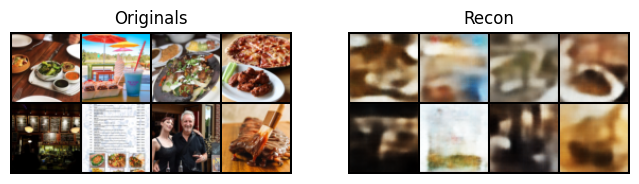

In [17]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

model.eval()
with torch.no_grad():
    imgs = next(iter(loader))[:8].to(device)
    recon, _, _ = model(imgs)

grid_orig  = make_grid(imgs.cpu(),  nrow=4, normalize=True)
grid_recon = make_grid(recon.cpu(), nrow=4, normalize=True)

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(8,4))
ax1.imshow(grid_orig.permute(1,2,0)); ax1.set_title("Originals");  ax1.axis('off')
ax2.imshow(grid_recon.permute(1,2,0));ax2.set_title("Recon");      ax2.axis('off')
plt.show()


In [18]:

os.makedirs('/content/vae_models', exist_ok=True)
torch.save(model.state_dict(),    '/content/vae_models/vae_full.pth')
torch.save(model.dec.state_dict(),'/content/vae_models/decoder.pth')
print(" Saved VAE and decoder to /content/vae_models/")


 Saved VAE and decoder to /content/vae_models/
